<a href="https://colab.research.google.com/github/simjonghyeon04/-/blob/main/3%EC%A3%BC%EC%B0%A8%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

sns.set(style="whitegrid")

data = fetch_openml(name='credit-g', as_frame=True)
df = data.frame

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 1. 데이터 개요

- 데이터명: credit-g
- 목적: 신용 등급 분류 (Good / Bad)
- 데이터 크기: 1000개 샘플, 다수 변수 포함

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


## 2. 수치형 변수 분석

각 수치형 변수의 분포를 확인하기 위해 히스토그램과 KDE를 활용하였다.

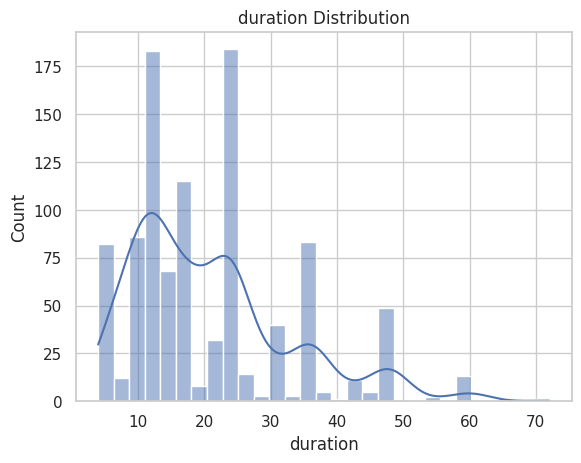

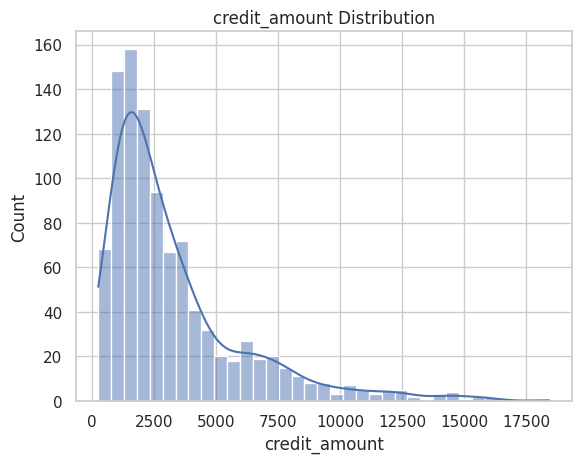

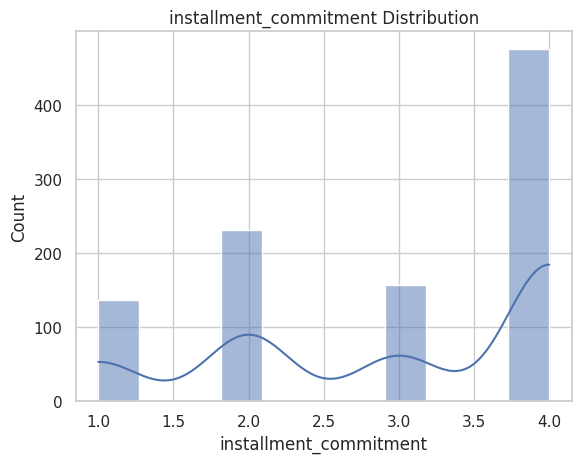

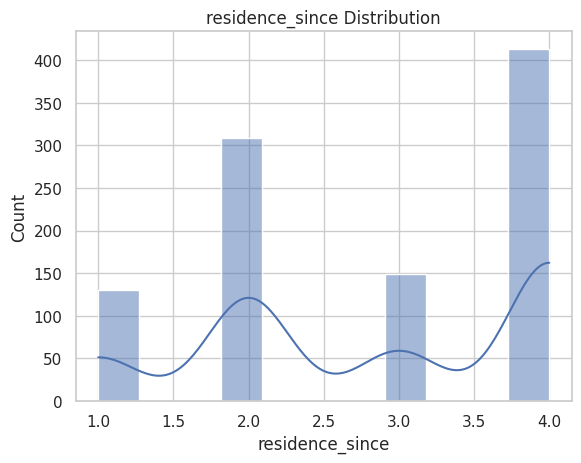

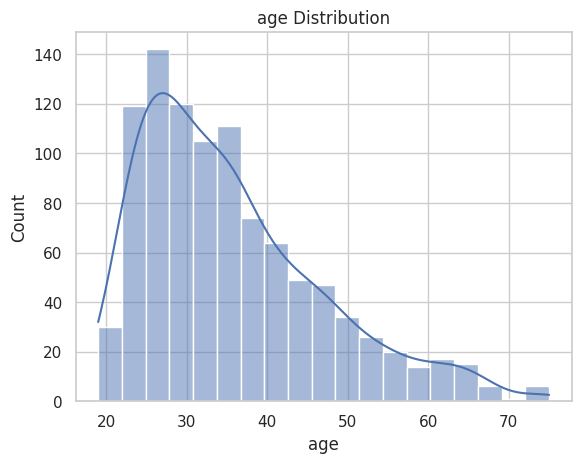

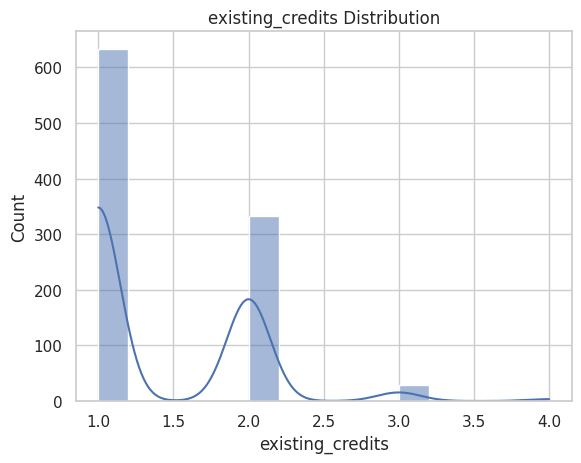

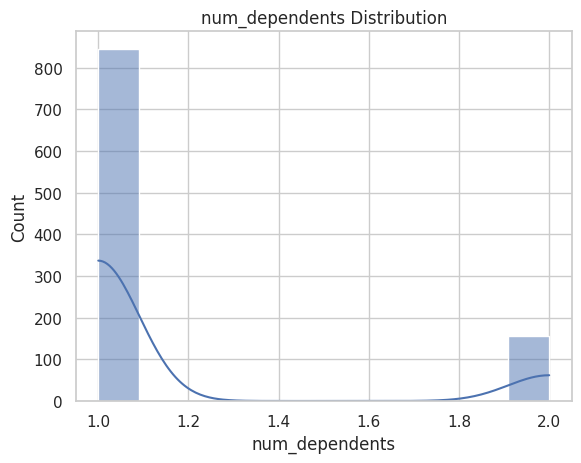

In [4]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [6]:
df[num_cols].skew()
df[num_cols].kurtosis()

,0
duration,0.919781
credit_amount,4.292590
installment_commitment,-1.210473
residence_since,-1.381449
age,0.595780
existing_credits,1.604439
num_dependents,1.649274


## 3. 범주형 변수 분석

범주형 변수의 클래스 분포를 확인하였다.

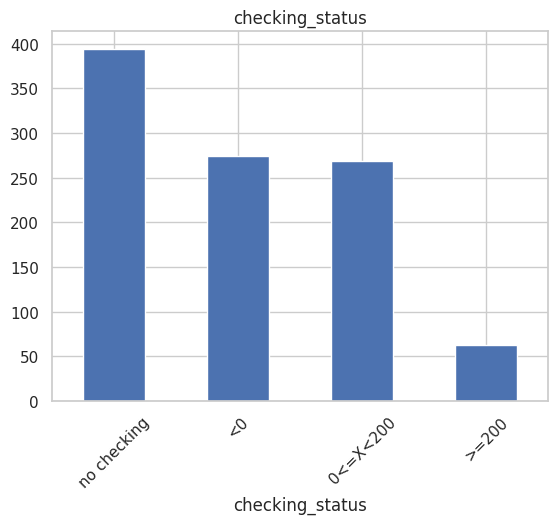

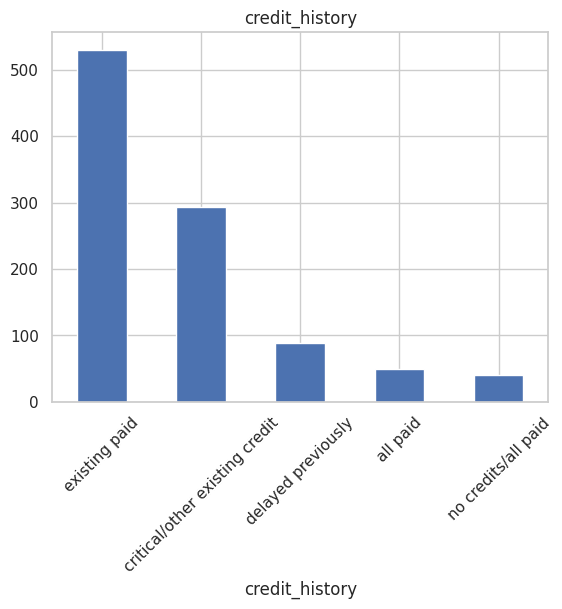

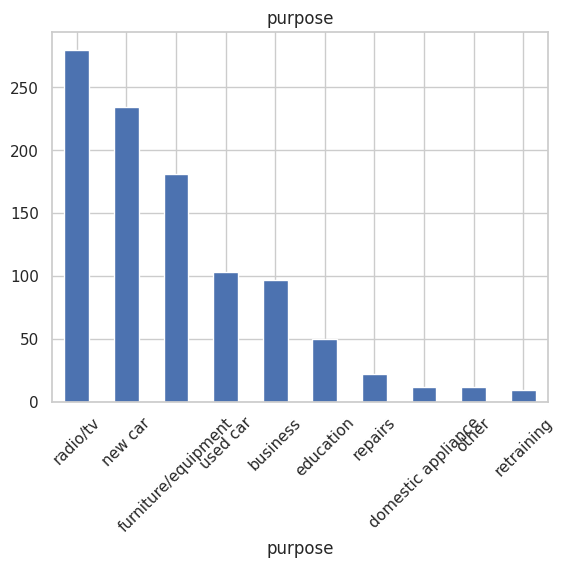

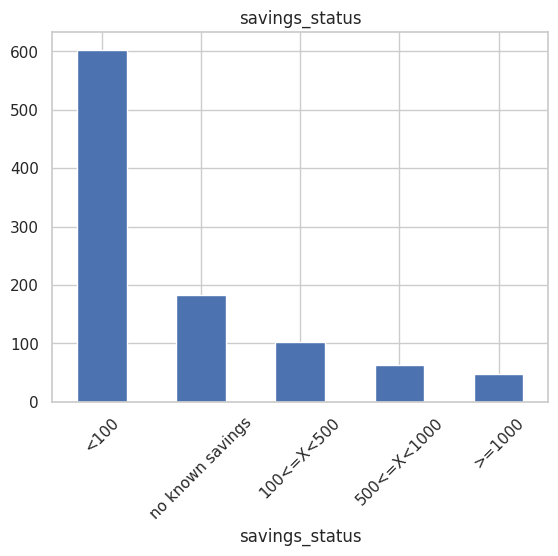

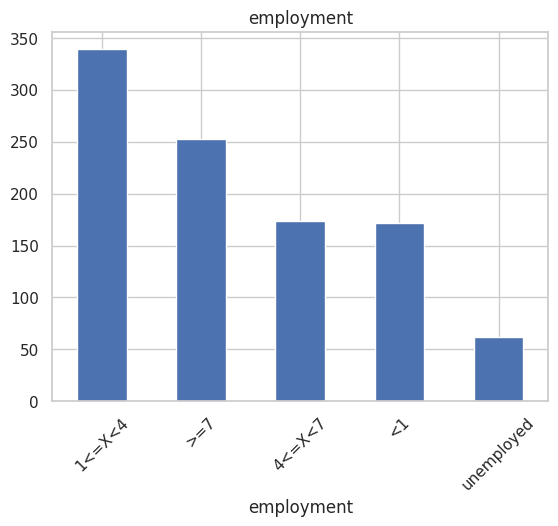

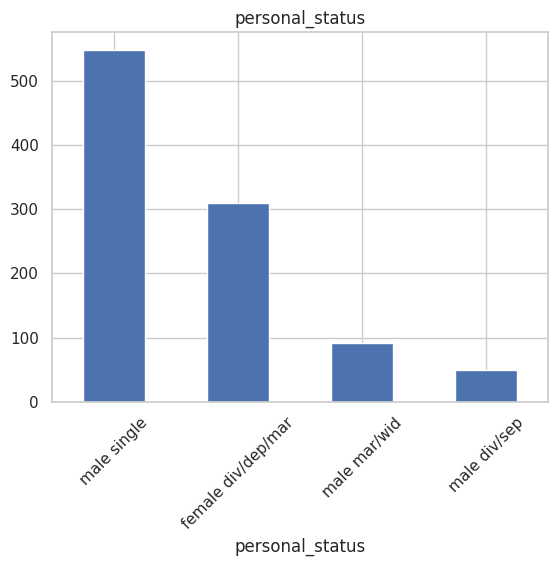

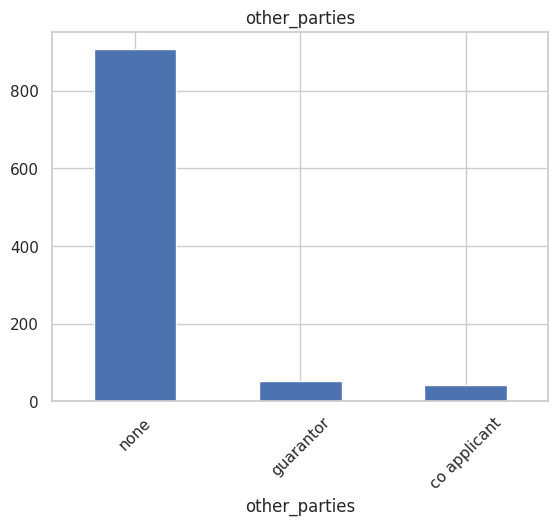

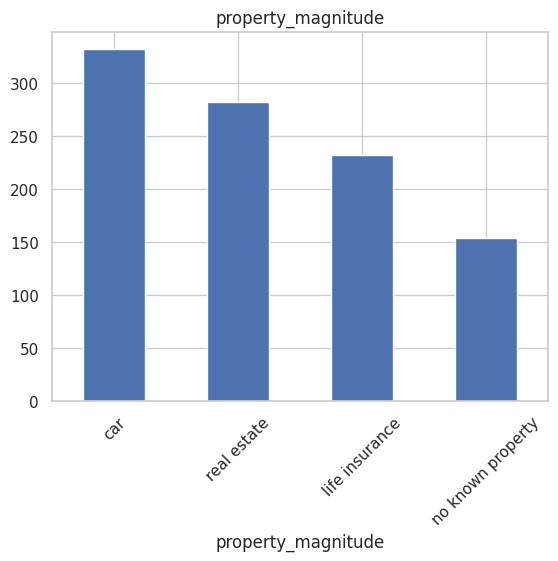

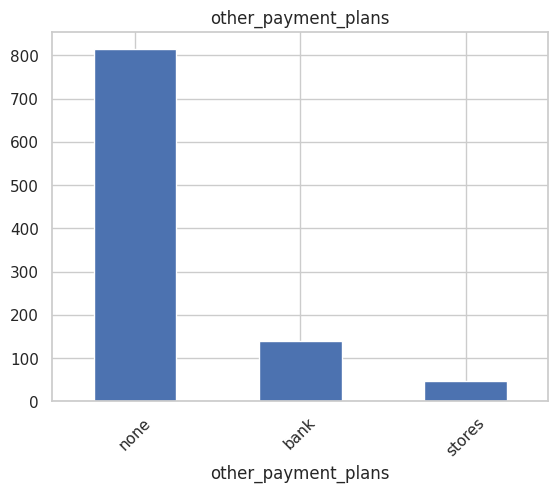

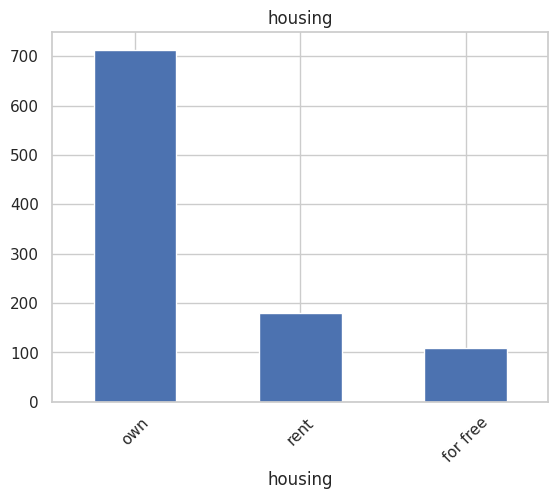

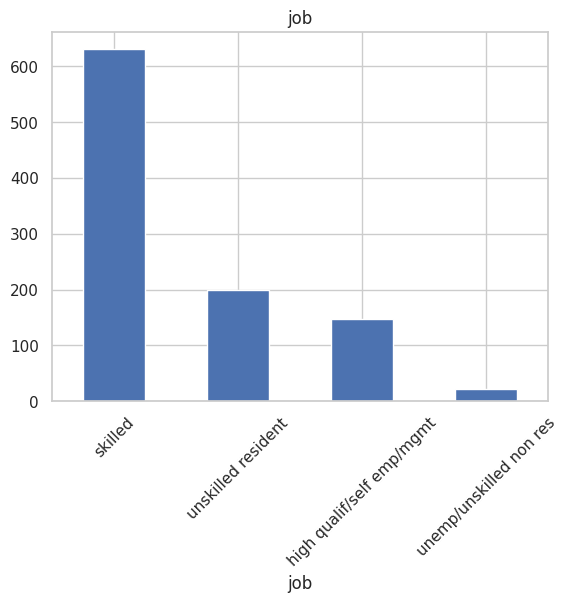

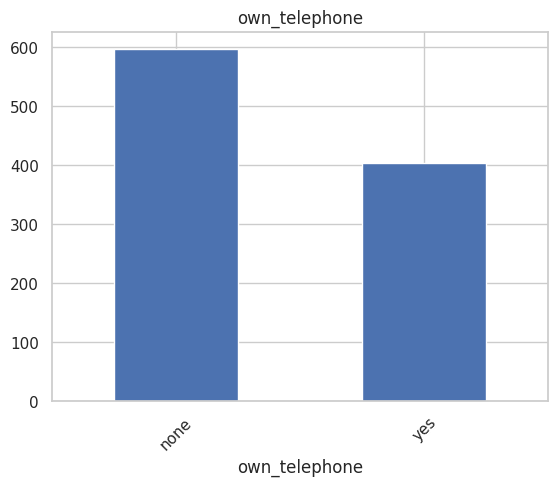

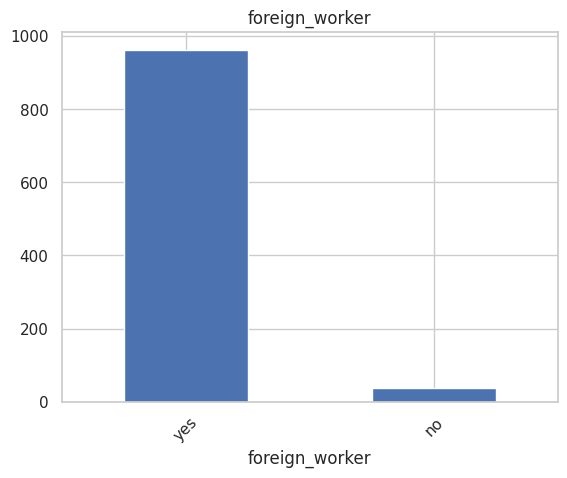

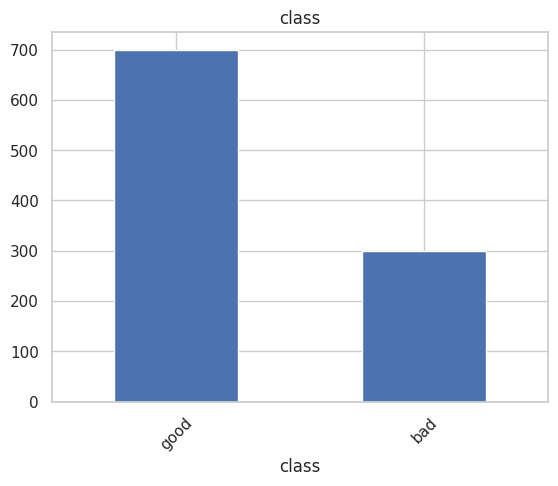

In [7]:
cat_cols = df.select_dtypes(include='category').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

## 4. 상관관계 분석

수치형 변수 간 상관관계를 확인하였다.

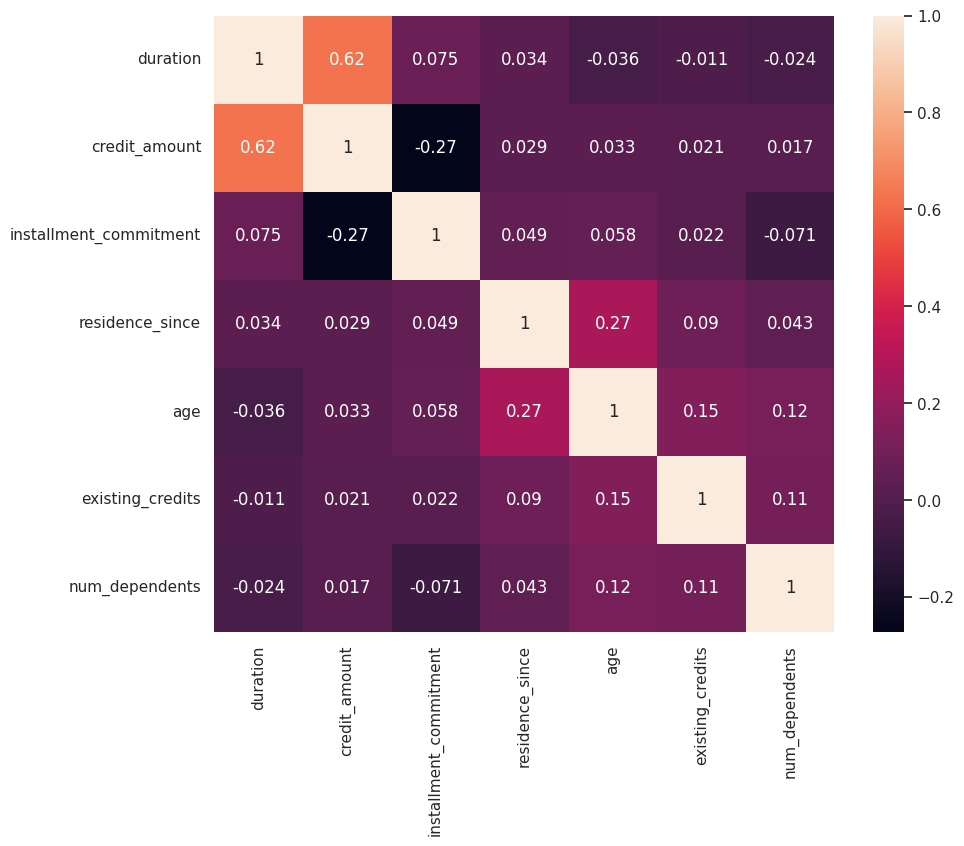

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()

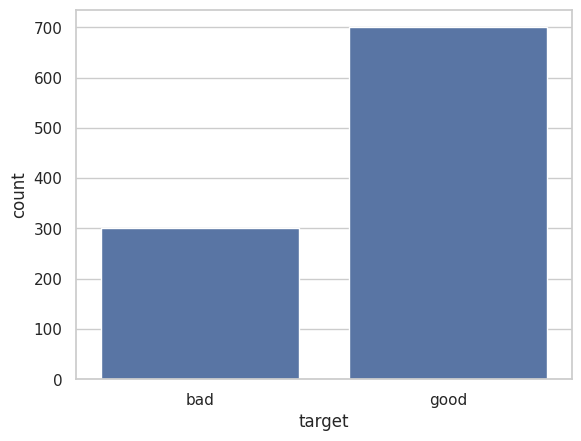

In [9]:
df['target'] = data.target

sns.countplot(x='target', data=df)
plt.show()

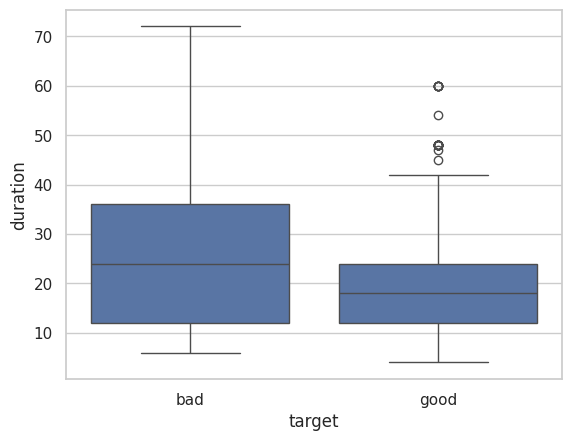

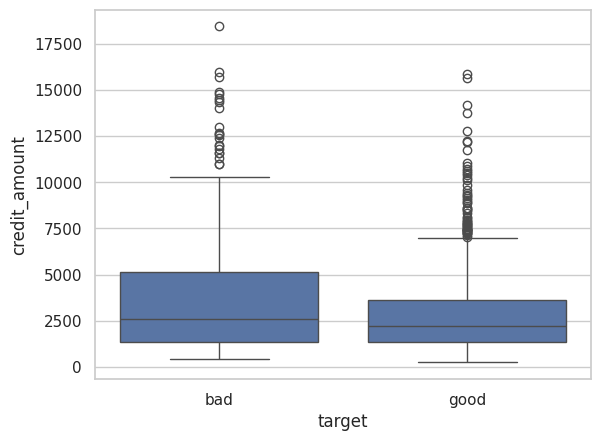

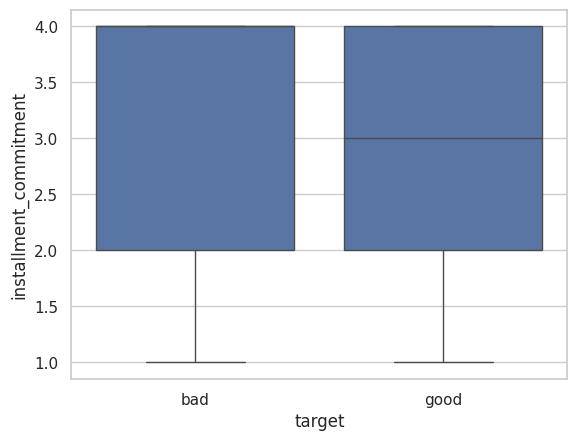

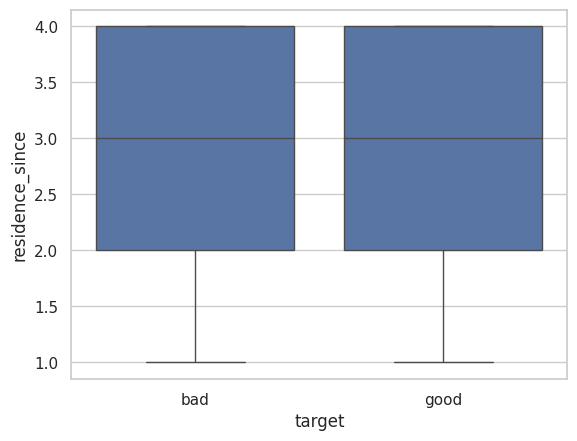

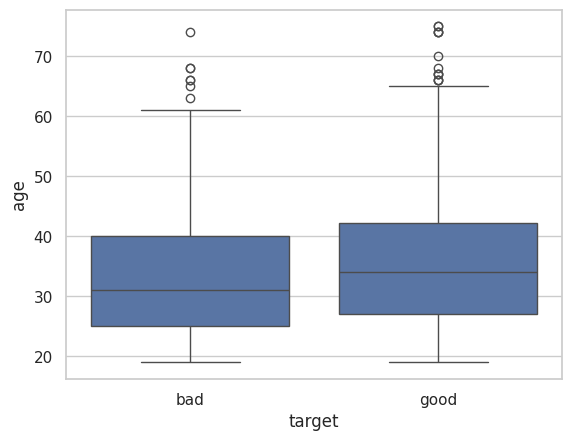

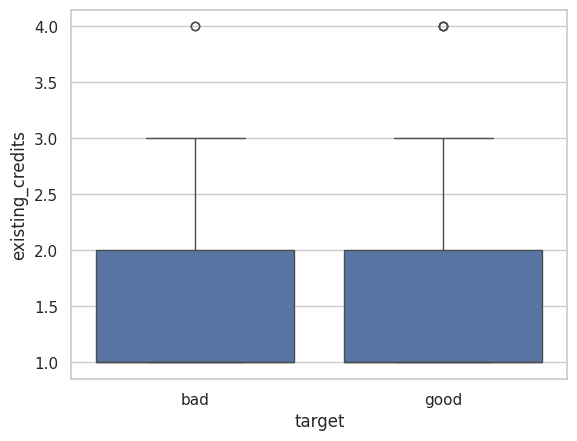

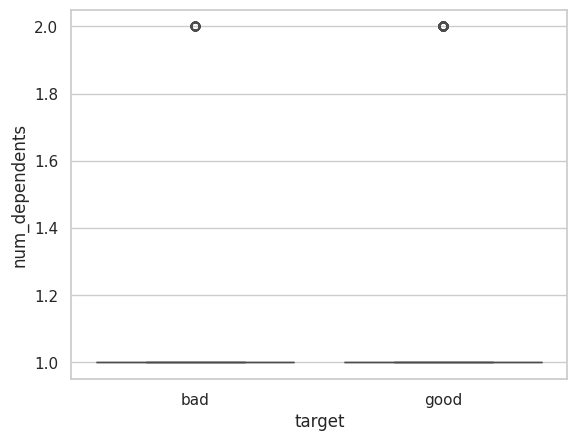

In [10]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='target', y=col, data=df)
    plt.show()

## 5. 결론

- 일부 변수는 정규분포를 따르지 않고 왜도가 존재하였다.
- 타겟 변수는 다소 불균형한 분포를 보였다.
- 특정 변수는 타겟에 따라 차이를 보이며, 이는 모델링에 유의미한 영향을 줄 수 있다.

향후 머신러닝 모델을 적용하여 예측 성능을 평가할 수 있다.